In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [2]:
IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 50

In [3]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "Potato",
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 4627 files belonging to 5 classes.


In [4]:
class_names = dataset.class_names
class_names

['Pepper__bell___Bacterial_spot',
 'Pepper__bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy']

In [5]:
len(dataset)

145

In [6]:
for image_batch, labels_batch in dataset.take(1):
    print(image_batch.shape)
    print(labels_batch.numpy())

(32, 256, 256, 3)
[3 3 3 0 2 1 1 3 2 1 1 0 0 0 4 2 0 4 3 1 4 2 3 2 2 1 0 0 2 1 2 3]


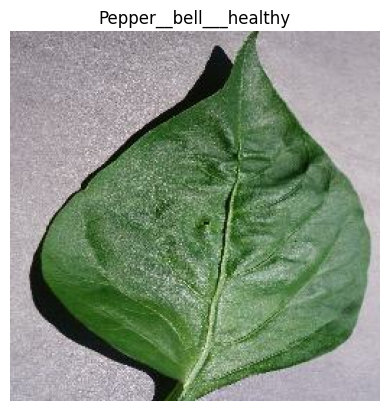

In [7]:
for image_batch, labels_batch in dataset.take(1):
    plt.imshow(image_batch[0].numpy().astype("uint8"))
    plt.title(class_names[labels_batch[0]])
    plt.axis("off")

In [8]:
len(dataset)

145

In [9]:
train_size = int(len(dataset) * 0.8)
train_size

116

In [19]:
train_ds = dataset.take(116)
len(train_ds)

116

In [20]:
test_ds = dataset.skip(116)
len(test_ds)

29

In [22]:
val_size = 0.1
len(dataset)*val_size

14.5

In [23]:
val_ds = test_ds.take(14)
len(val_ds)

14

In [24]:
test_ds = test_ds.skip(14)
len(test_ds)

15

In [25]:
print(len(train_ds))
print(len(val_ds))
print(len(test_ds))

116
14
15


In [26]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    ds_size = len(ds)
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)

    train_ds = ds.take(train_size)

    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    return train_ds, val_ds, test_ds

In [27]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [31]:
len(test_ds)

15